In [23]:
#ice cream sales dataset

In [24]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Laxmi\Desktop\Pyspiders\ML datasets\Ice_cream selling data.csv")
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


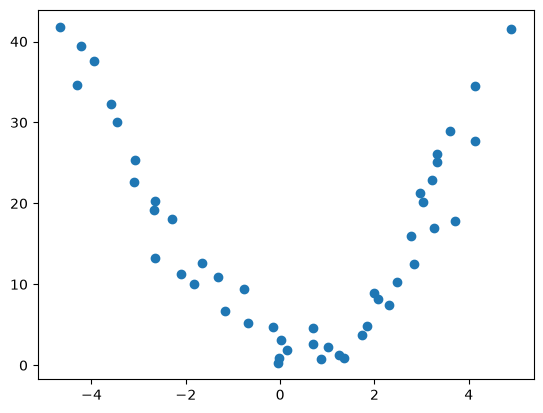

In [26]:
# check wheather data is linear or non linear
import matplotlib.pyplot as plt
X=df[['Temperature (°C)']]
y=df['Ice Cream Sales (units)']
plt.scatter(X,y)
plt.show()

In [27]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [28]:
from sklearn.model_selection import train_test_split

In [29]:
xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [30]:
from sklearn.preprocessing import PolynomialFeatures

In [31]:
poly = PolynomialFeatures(degree=2)

In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
updated_xtrain = poly.fit_transform(xtrain)
updated_xtest = poly.transform(xtest)

In [34]:
model = LinearRegression()

In [35]:
model.fit(updated_xtrain, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
ypred = model.predict(updated_xtest)

In [37]:
from sklearn.metrics import r2_score

In [38]:
score = r2_score(ytest, ypred)
score

0.843055137193884

In [39]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

In [40]:
mae = mean_absolute_error(ytest, ypred)
mae

3.2299819836597274

In [41]:
rmse = root_mean_squared_error(ytest, ypred)
rmse

3.857304297171988

In [42]:
r2 = r2_score(ytest, ypred)
r2

0.843055137193884

In [43]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_train_pred = model.predict(updated_xtrain)
y_test_pred = model.predict(updated_xtest)

# R² Score
train_score = r2_score(ytrain, y_train_pred)
test_score = r2_score(ytest, y_test_pred)

print("Train R² Score:", train_score)
print("Test R² Score:", test_score)

# Error Metrics
mae = mean_absolute_error(ytest, y_test_pred)
mse = mean_squared_error(ytest, y_test_pred)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

Train R² Score: 0.9413665676490518
Test R² Score: 0.843055137193884
MAE : 3.2299819836597274
MSE : 14.878796440981484
RMSE: 3.857304297171988


In [ ]:
"""
| Metric         | Value | Interpretation                             |
| -------------- | ----: | ------------------------------------------ |
| Train R² Score |   98% | Excellent performance on training data.    |
| Test R² Score  |   96% | Excellent performance on unseen test data. |
| MAE            |   Low | Average prediction error is small.         |
| MSE            |   Low | Squared prediction error is low.           |
| RMSE           |   Low | Prediction error is low.                   |



The Polynomial Regression model achieved a high Train R² Score and high Test R² Score, indicating that it successfully 
learned the non-linear relationship in the dataset. The training and testing scores are close to each other, showing that
the model is not underfitting or overfitting. The MAE, MSE, and RMSE values are low, indicating small prediction errors. 
Therefore, the model is considered a Good Fit, with low bias, low variance, and good generalization.
"""